16 recordings
subject       date                                                     file
    M01 2024-03-08          sub-M01/sub-M01_ses-20240308T100000_ecephys.nwb
    M01 2024-03-12 sub-M01/sub-M01_ses-20240312T100000_behavior+ecephys.nwb
    M01 2024-03-13 sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb
    M01 2024-03-14 sub-M01/sub-M01_ses-20240314T100000_behavior+ecephys.nwb
    M01 2024-03-18 sub-M01/sub-M01_ses-20240318T100000_behavior+ecephys.nwb
    M02 2024-03-12 sub-M02/sub-M02_ses-20240312T100000_behavior+ecephys.nwb
    M02 2024-03-13 sub-M02/sub-M02_ses-20240313T100000_behavior+ecephys.nwb
    M02 2024-03-14 sub-M02/sub-M02_ses-20240314T100000_behavior+ecephys.nwb
    M02 2024-03-18 sub-M02/sub-M02_ses-20240318T100000_behavior+ecephys.nwb
    M03 2024-06-21 sub-M03/sub-M03_ses-20240621T100000_behavior+ecephys.nwb
    M03 2024-06-22 sub-M03/sub-M03_ses-20240622T100000_behavior+ecephys.nwb
    M03 2024-06-23 sub-M03/sub-M03_ses-20240623T100000_behavior+ecephys.nw

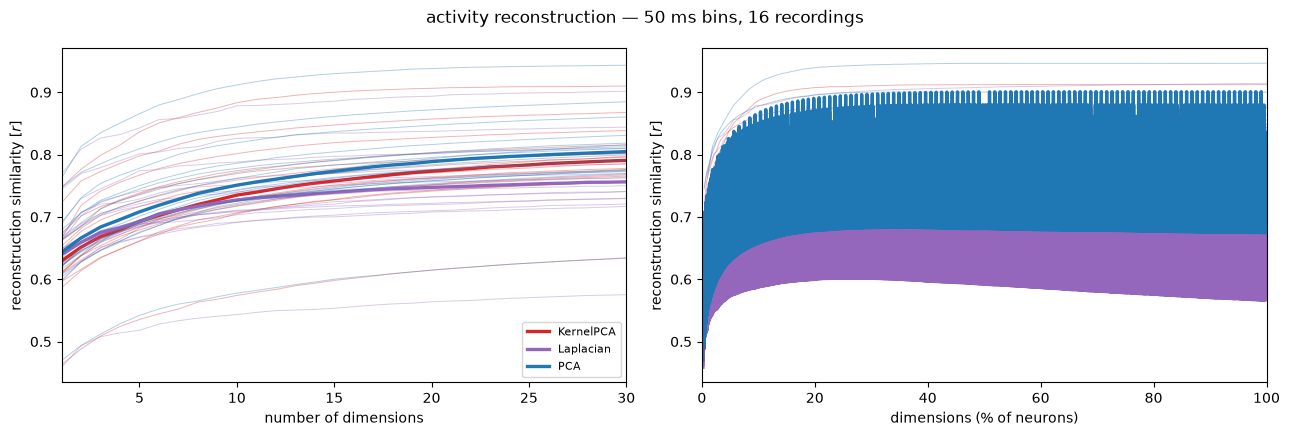

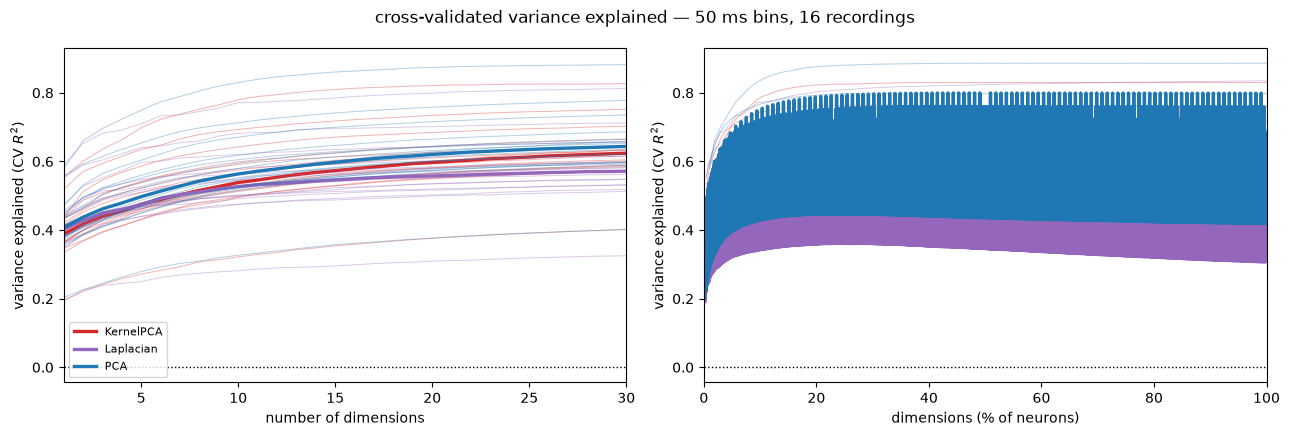

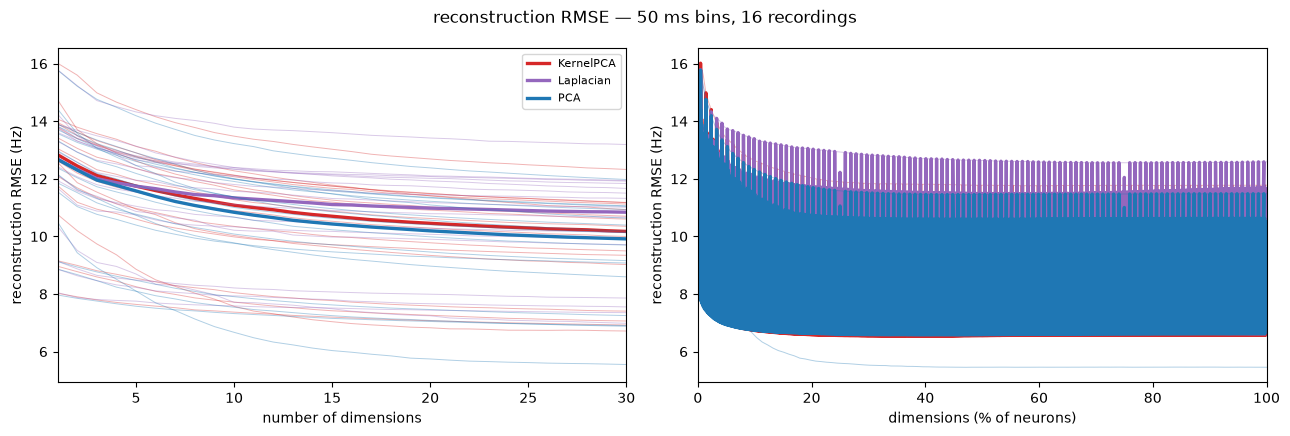

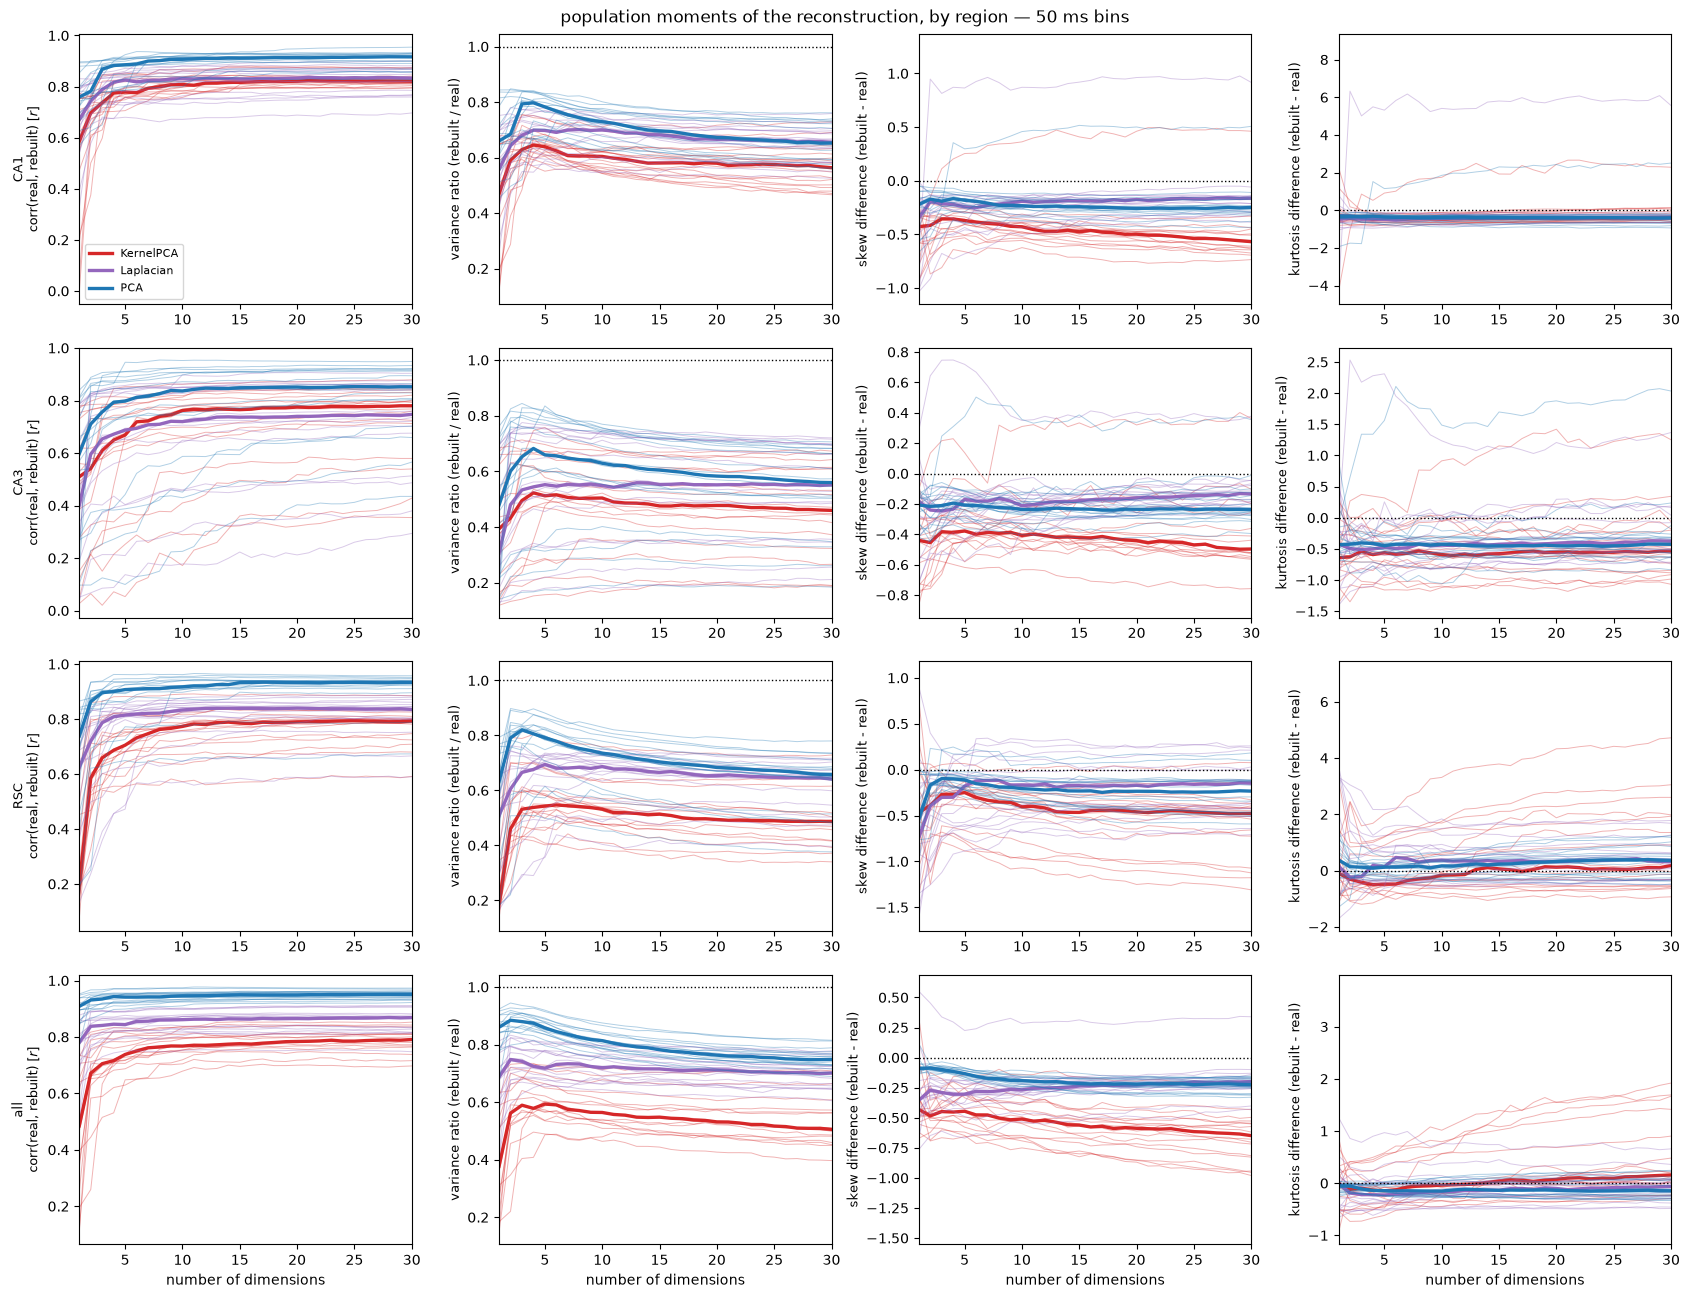

intrinsic dimensionality (correlation dimension), by method
           count  mean   50%   min   max
method                                  
KernelPCA   16.0  2.85  2.86  2.67  3.03
Laplacian   16.0  1.83  1.82  1.33  2.23
PCA         16.0  2.49  2.50  2.15  2.69


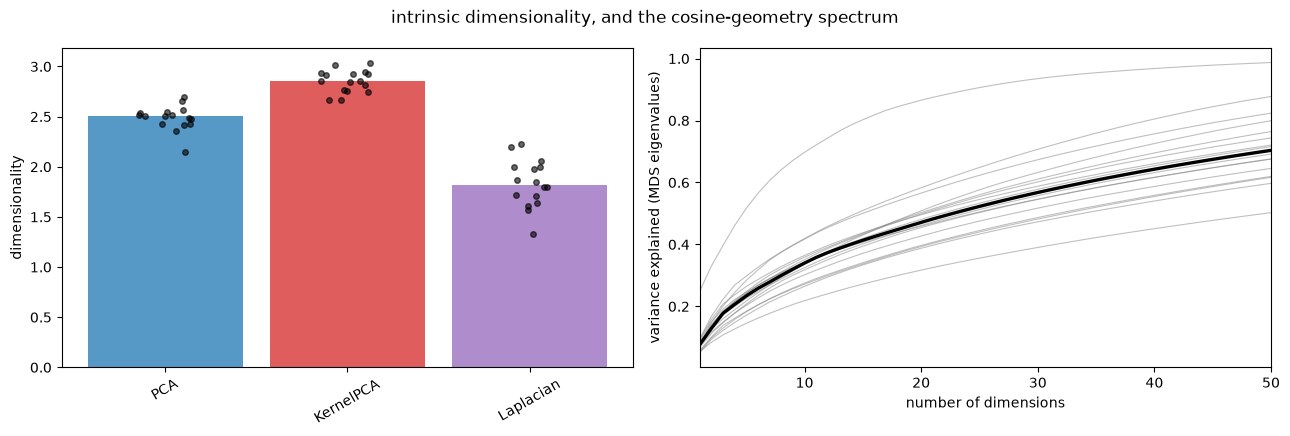

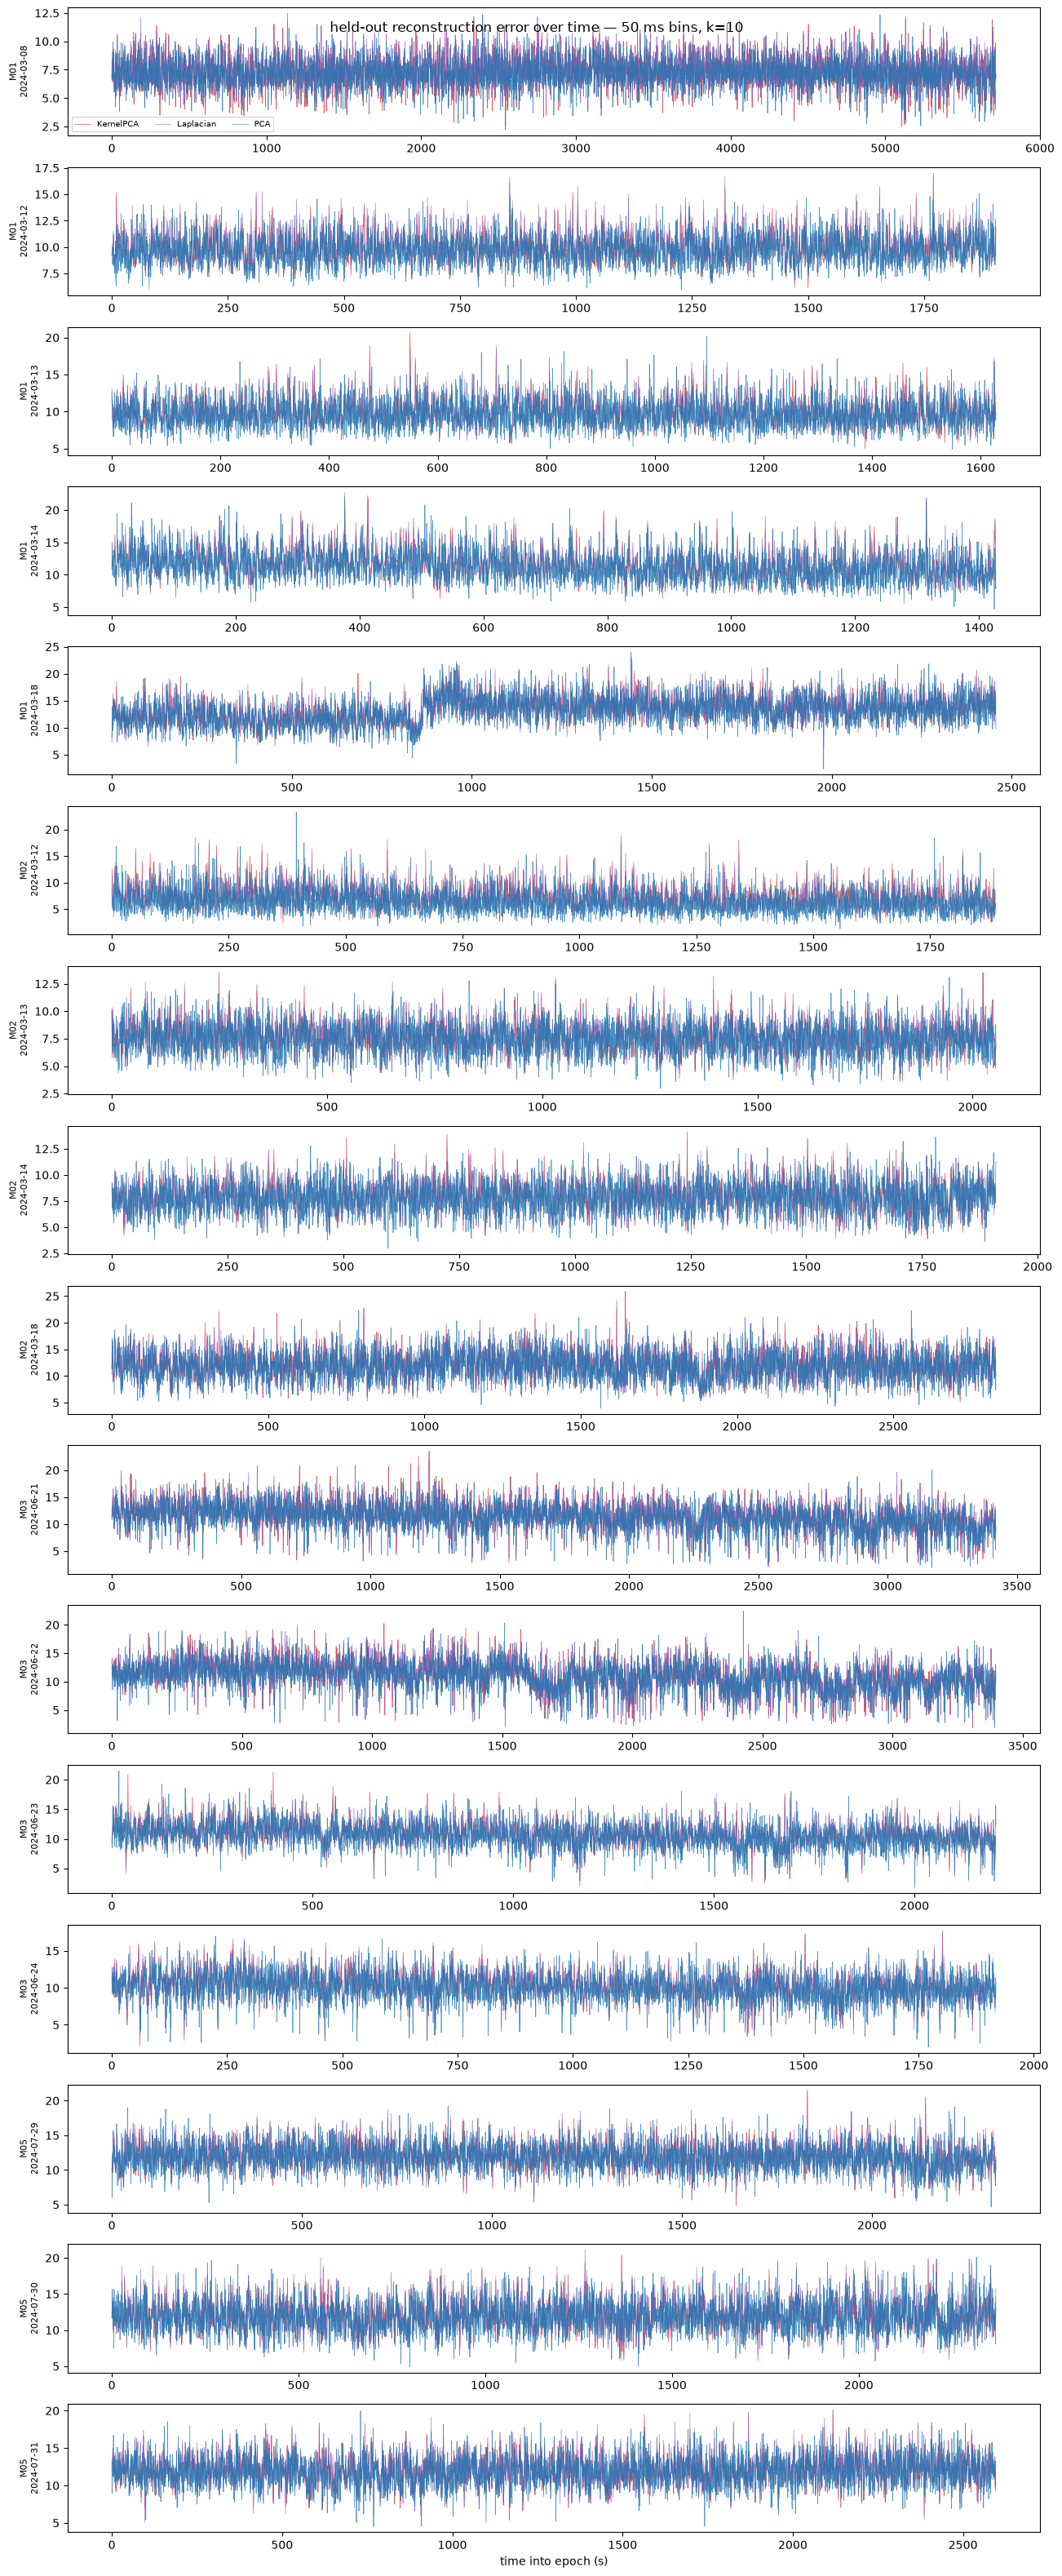


how much the error moves within a session — 50 ms bins, k=10
                              median     p10        p90  p90_over_p10
subject date       method                                            
M01     2024-03-08 KernelPCA   7.205   5.890   8.854000         1.503
                   Laplacian   7.393   6.086   9.064000         1.489
                   PCA         7.206   5.821   8.772000         1.507
        2024-03-12 KernelPCA   9.710   8.231  11.669000         1.418
                   Laplacian  10.116   8.468  12.138000         1.433
                   PCA         9.621   7.977  11.358000         1.424
        2024-03-13 KernelPCA   9.595   7.833  12.383000         1.581
                   Laplacian   9.821   7.895  12.483000         1.581
                   PCA         9.413   7.447  12.009000         1.613
        2024-03-14 KernelPCA  11.216   8.877  14.483000         1.631
                   Laplacian  11.636   9.101  14.903000         1.638
                   PCA      

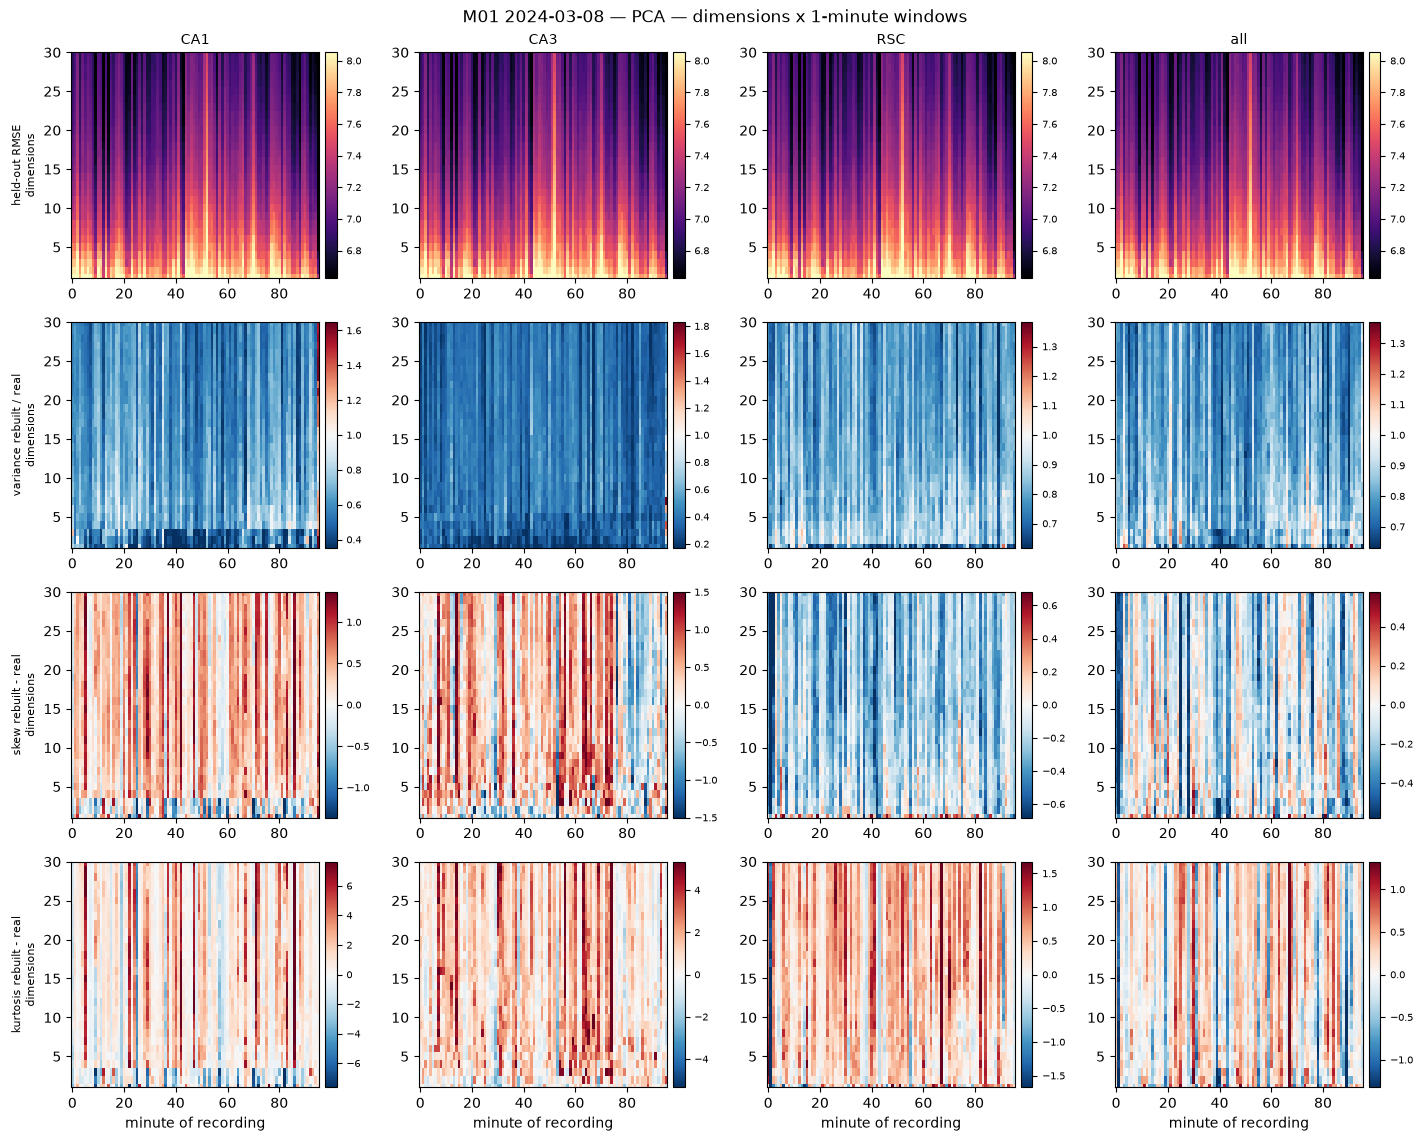

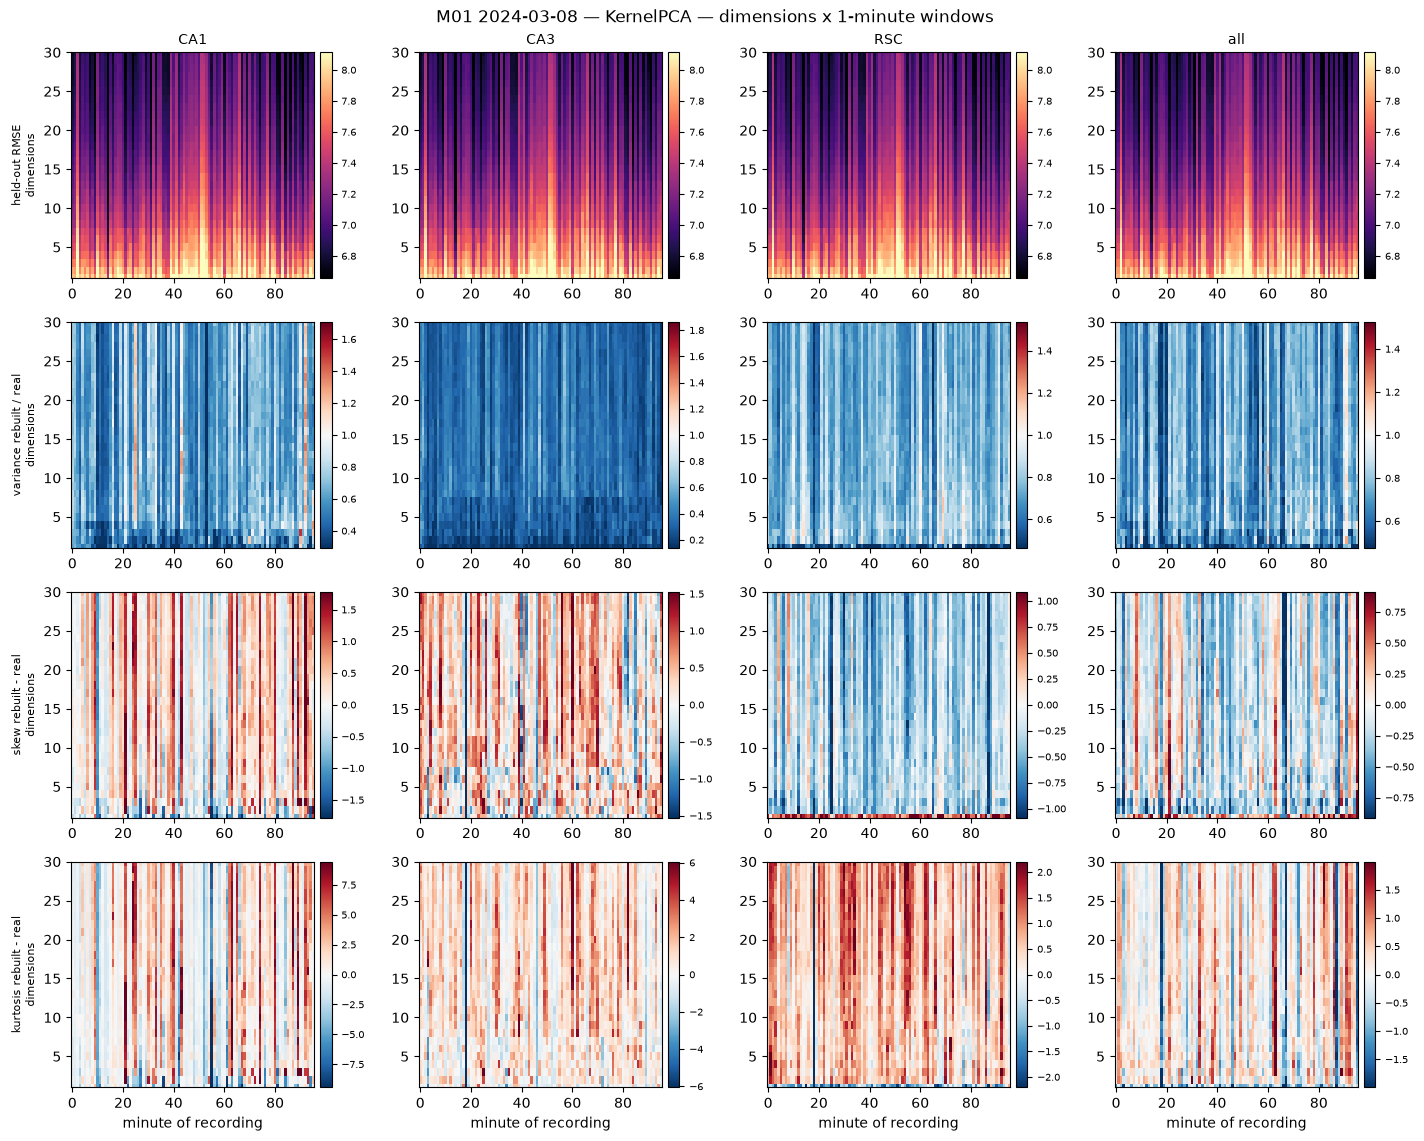

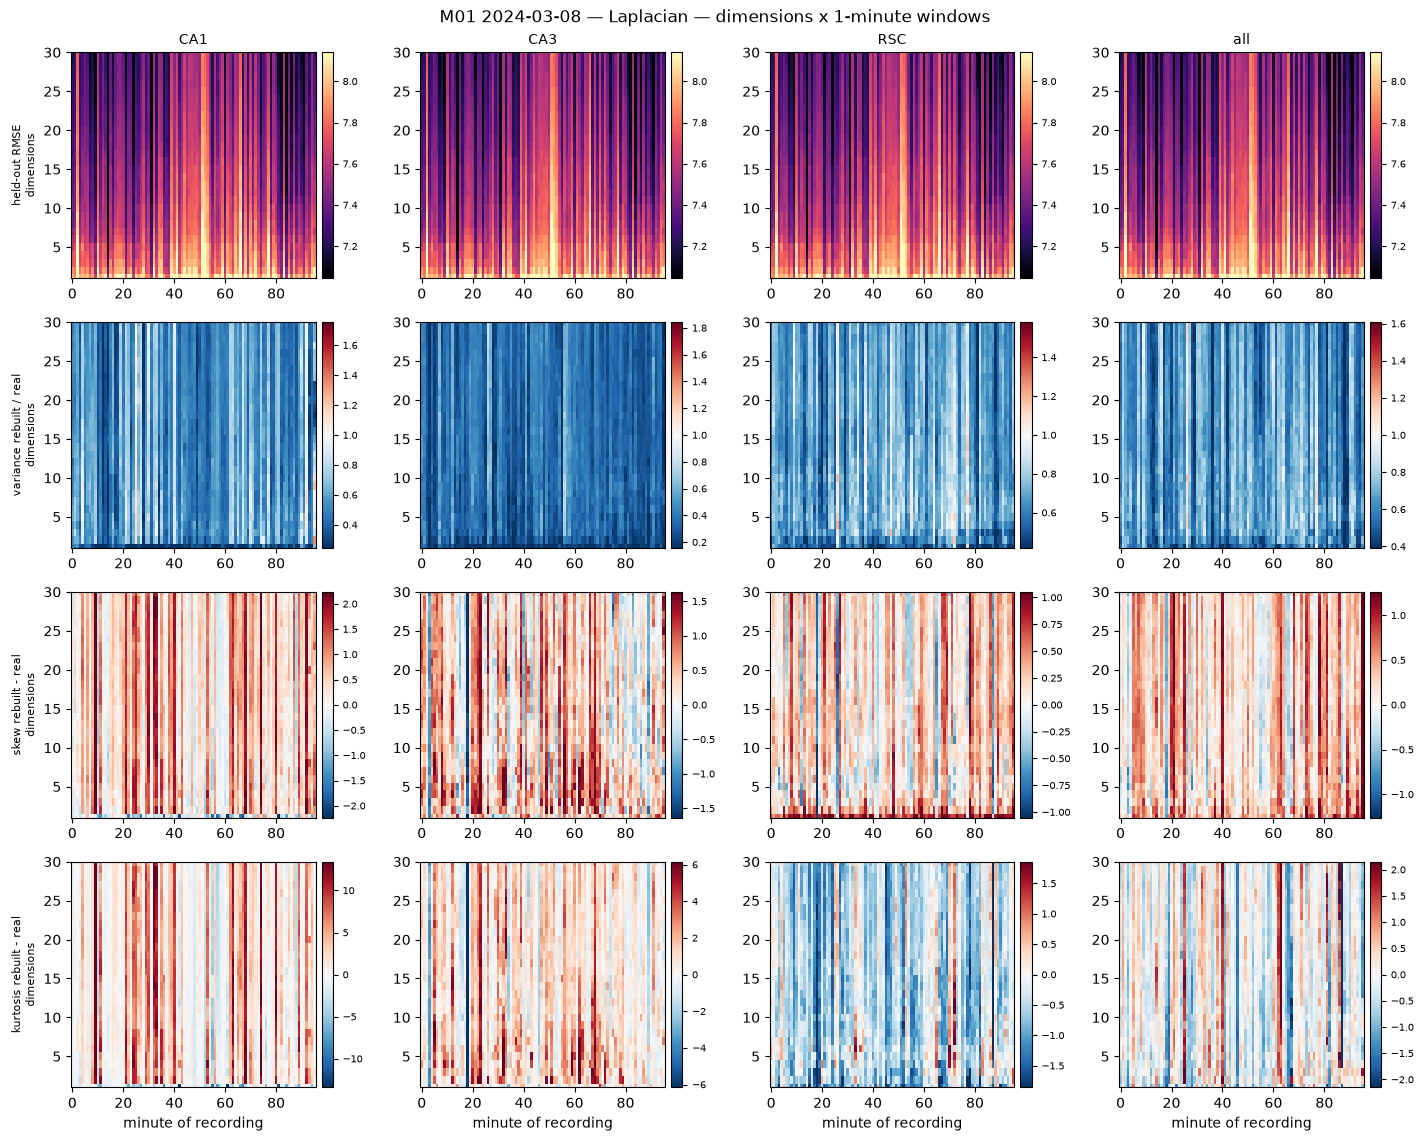

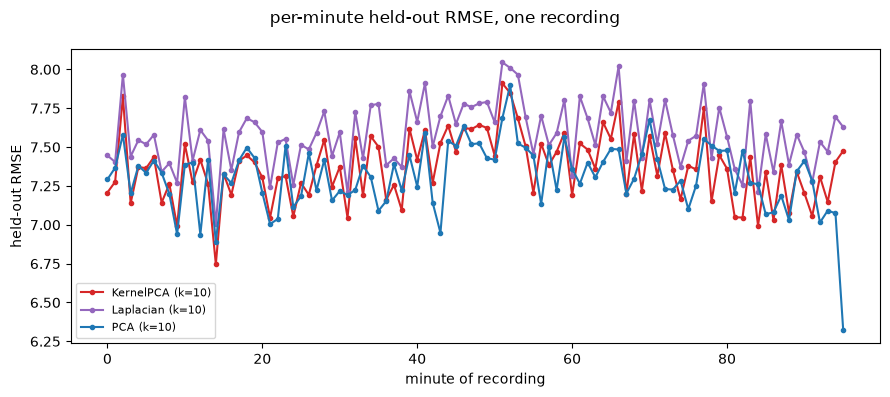

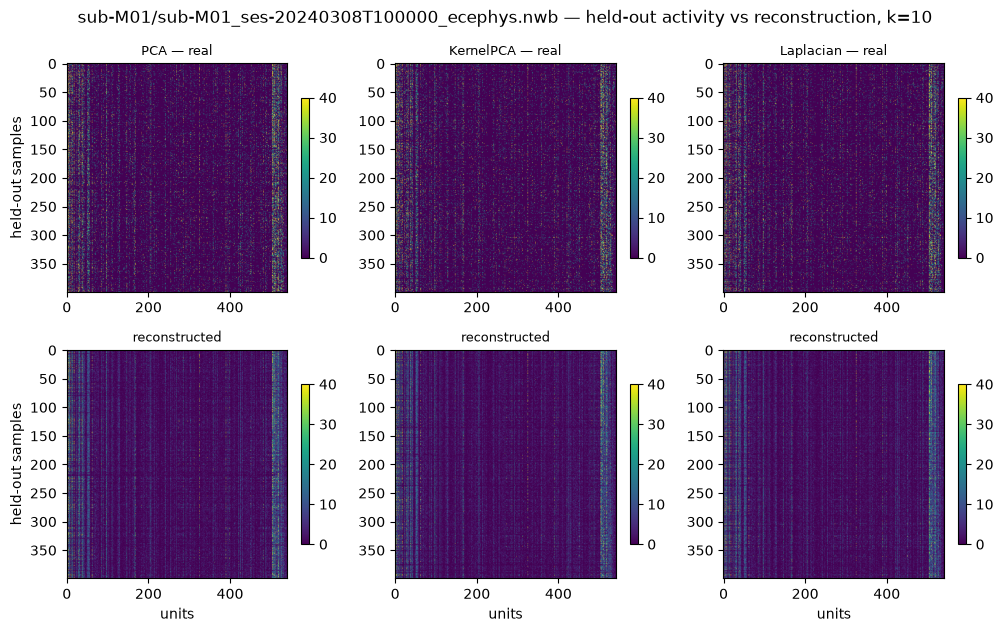

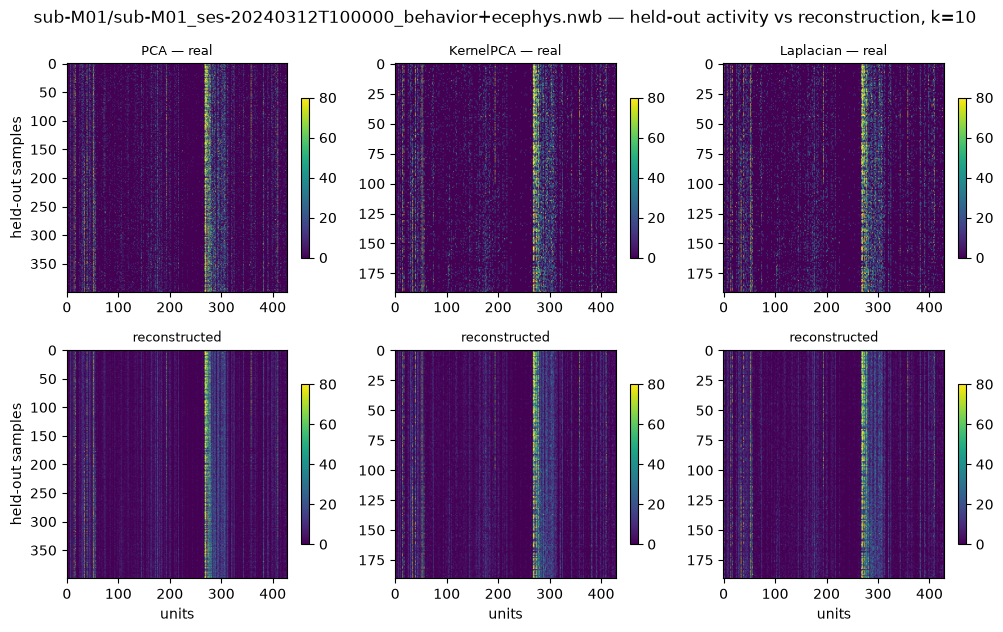

In [1]:
"""Neural manifold evaluation, following schultzlab/Neural_Manifolds.

PCA, kernel PCA and Laplacian eigenmaps over every recording in the dandiset,
scored the way Neural_Manifold_Learning_CA1.ipynb scores them. Nothing is
written to disk.

Their pipeline, reimplemented here because NMLfunc.py is not vendored:

    X                cosine distances on the binned activity, downsampled
    embedding        fit on X, then normalized by max|x_embd|
    variance         cumulative eigenvalue spectrum of classical MDS on the
    explained        cosine distance matrix, a property of the data rather
                     than of any one method
    reconstruction   out-of-sample LLE mapping from embedding back to
                     activity (K_LLE neighbours, LAMBDA regularization),
                     10-fold CV with a randomly drawn held-out tenth, scored
                     by corr(real, reconstructed) and RMSE. Some holdout is
                     unavoidable: query the set the mapping was built from and
                     every point finds itself among its own neighbours
    dimensionality   correlation dimension: neighbour count against radius,
                     log-log slope over the middle of the range

One thing of theirs is deliberately absent: their RMSE figure is an optimal
linear estimator decoding behaviour out of the embedding. This is an analysis
of the activity itself, so there is no behaviour in it at all — no position, no
speed, no decoding. RMSE here means reconstruction RMSE.

Added on top of theirs, and marked as such where they appear:

    CV R^2           1 - MSE(X_test, X_rec) / MSE(X_test, mean) — their
                     commented-out var_expl line, uncommented
    moments          variance, skew and kurtosis of the POPULATION signal —
                     the summed activity, per brain region — in the data and
                     in the reconstruction. Not per neuron: a single neuron's
                     moments over a held-out fold are mostly sampling noise,
                     and the population sum is the thing the manifold is
                     supposed to be a description of
    per-minute       held-out error resolved by dimension and by one-minute
                     window, as heatmaps, for one example recording. One
                     embedding is fit per recording, so its error is an
                     average over minutes that are not alike, and this is
                     where that average comes apart
    simulation       DATA_SOURCE = "simulated" replaces the dandiset with a
                     synthetic population of known latent dimensionality.
                     It runs in seconds and the right answer is known, so
                     the pipeline can be debugged without waiting on real
                     data, and the estimators can be checked against a truth

CELL 1  config, loaders, the sweep. Leaves `scores`, `spectra`, `timepoints`,
        `minutes`
CELL 2  reconstruction similarity, RMSE and cross-validated R^2
CELL 3  population moments by region, against dimensions
CELL 4  intrinsic dimensionality, and the MDS variance-explained spectrum
CELL 5  held-out error over time
CELL 6  dimension x minute heatmaps from one recording: error, variance,
        skew, kurtosis
CELL 7  a real-vs-reconstructed example
"""

import gc
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynapple as nap
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors

# =============================================================================
# CONFIG — everything sweepable lives here
# =============================================================================

DOWNLOAD_DIR = Path("/storage/dandi_downloads").resolve()

# Where the computed reductions go: one .npz per recording x bin size x
# method, holding the embedding and the indices of the bins it was fit on,
# plus the result frames as CSVs at the end of the sweep. A run checks this
# directory first and reuses whatever is already there, so a killed sweep does
# not refit what it already finished — which matters most for Laplacian
# eigenmaps, where the fit alone is several minutes.
CACHE_DIR = Path("/storage/manifold_embeddings")
USE_CACHE = True                  # read existing embeddings and skip the fit
SAVE_CACHE = True                 # write embeddings as they are computed
SAVE_RESULTS = True               # write the score frames at the end of cell 1

# "nwb" reads the dandiset. "simulated" generates a synthetic population with
# a known number of latent dimensions instead — a few seconds per recording,
# and the answer is known, so it is the thing to debug against. If the
# reconstruction curve does not saturate near SIM_LATENT_DIM on simulated
# data, the pipeline is wrong and nothing it says about real data is worth
# reading.
DATA_SOURCE = "nwb"               # "nwb" | "simulated"
SIM_RECORDINGS = 3                # how many synthetic sessions to generate
SIM_UNITS = 150
SIM_DURATION_S = 600.0
SIM_LATENT_DIM = 4                # the ground truth the curves should find
SIM_SMOOTH_S = 0.5                # timescale of the latent trajectories
SIM_GAIN = 0.8                    # how strongly latents modulate log rate
SIM_BASE_RATE_HZ = 5.0
SIM_REGIONS = 3

RECORDINGS = None                 # None = all; or substrings e.g. ["sub-M05"]
MAX_RECORDINGS = None             # cap for a smoke test
EPOCH = "maze"                    # "maze" (position-tracked span) | "full"

BIN_SIZES_S = (0.050,)            # swept
RATE_TRANSFORM = "none"           # "none" (raw Hz) | "sqrt" | "zscore"
MIN_RATE_HZ = 0.0

# --- their parameters --------------------------------------------------------
K_LLE = 10                        # neighbours for the LLE reconstruction
LAMBDA = 1.0                      # regularization on the local Gram matrix
RECON_STRIDE = 2                  # they reconstruct on X[::2]

# How the reconstruction is held out. Some holdout is needed at all because
# the LLE mapping rebuilds a point from its nearest neighbours: query the set
# it was built from and each point finds itself, so the score measures
# memorization rather than structure.
#
#   "kfold"  CV_FOLDS passes; each one holds out a random tenth and rebuilds
#            it from the other nine tenths. The default.
#   "split"  two complementary halves, two passes — the cheap version.
#
# RECON_SHUFFLE picks the partition. True draws the held-out tenth at random,
# which is the usual convention. False takes it as one contiguous block of
# time, which is stricter here: consecutive 50 ms bins are highly correlated,
# so a randomly held-out bin usually has its immediate neighbours sitting in
# the training set, and the score comes out better than the embedding deserves.
RECON_VALIDATION = "kfold"        # "kfold" | "split"
CV_FOLDS = 10
RECON_SHUFFLE = True              # random partition; False = contiguous blocks
RECON_SEED = 0
# ...and then capped, because the embedding is now fit on every bin. The LLE
# reconstruction runs CV_FOLDS times at every evaluated dimension, so its cost
# is what has to be bounded — the fit itself is cheap by comparison.
RECON_MAX_SAMPLES = 5000
ID_NSTEP = 30                     # radii steps for the correlation dimension
ID_THR_START, ID_THR_FI = 100, 5e3   # neighbour-count range the slope is fit over
ID_DIMS = 5                       # embedding dims the dimensionality is measured on
SPECTRUM_DIMS = 50                # x-limit of the MDS variance-explained curve

# --- the methods -------------------------------------------------------------
# `downsample` is applied to the bins before fitting. PCA scales linearly in
# samples, so it is fit on every bin. Kernel PCA and Laplacian eigenmaps build
# an n_samples x n_samples matrix and cannot be, so they take every 10th bin —
# 50k bins would be a 20 GB kernel, 5k bins is 200 MB.
#
# ICA is deliberately absent. Its components maximize non-Gaussianity, not
# variance, so they come back in no particular order, and "the first k
# dimensions" — which is what every curve here is a function of — would mean
# whatever ordering we imposed on it. It is a source-separation method rather
# than a manifold one, and the reference notebook does not include it either.
METHODS = {
    "PCA": {"kind": "pca", "downsample": 1, "cap": None,
            "params": {"svd_solver": "auto"}},
    "KernelPCA": {"kind": "kernel_pca", "downsample": 10, "cap": None,
                  "params": {"kernel": "cosine", "eigen_solver": "auto"}},
    "Laplacian": {"kind": "laplacian", "downsample": 10, "cap": None,
                  "params": {"affinity": "nearest_neighbors", "n_neighbors": 15}},
}
METHOD_COLORS = {"PCA": "#1f77b4", "KernelPCA": "#d62728",
                 "Laplacian": "#9467bd"}

# Every dimension from 1 to the neuron count is scored — the curve is the
# whole curve, not a grid through it. FIRST_DIMS only sets the x-limit of the
# left-hand plot panels, where the drop-off is; the right-hand panels always
# run to 100% of the neuron count.
FIRST_DIMS = 30

TIME_K = 10                       # dims at which per-timepoint error is kept
EXAMPLE_K = 10                    # dims for the real-vs-reconstructed figure
VAR_THRESHOLDS = (0.5, 0.8, 0.9)

# --- the dimension x minute heatmaps ----------------------------------------
# Built for one recording only — they are a look at the inside of a single
# session, not a summary. None takes the first recording in the table; set a
# substring (e.g. "sub-M05_ses-20240731") to pick one.
EXAMPLE_FILE = None
MINUTE_S = 60.0                   # width of the time windows in the heatmaps
HEATMAP_MAX_DIMS = 30             # y-limit: dimensions included, in order


# =============================================================================
# STEP 1 — the recordings
# =============================================================================


def recording_table(root, patterns=RECORDINGS, limit=MAX_RECORDINGS):
    rows = []
    for path in sorted(Path(root).rglob("*.nwb")):
        if patterns and not any(p in str(path) for p in patterns):
            continue
        stem = path.stem
        subject = re.search(r"sub-([^_]+)", stem)
        session = re.search(r"ses-([^_]+)", stem)
        ses = session.group(1) if session else "unknown"
        rows.append({
            "subject": subject.group(1) if subject else path.parent.name,
            "session": ses,
            "date": f"{ses[:4]}-{ses[4:6]}-{ses[6:8]}" if len(ses) >= 8 else ses,
            "has_behavior": "behavior" in stem,
            "file": str(path.relative_to(root)),
        })
    table = pd.DataFrame(rows).sort_values(["subject", "session"]).reset_index(drop=True)
    return table.head(limit) if limit else table


def unit_regions(spike_group):
    """Brain region per unit, or "all" where the NWB carries no labels."""
    meta = getattr(spike_group, "metadata", None)
    if isinstance(meta, pd.DataFrame) and "cell_area" in meta.columns:
        return meta["cell_area"].astype(str).values
    try:
        return np.asarray(spike_group.get_info("cell_area")).astype(str)
    except Exception:
        return np.array(["all"] * len(spike_group.index))


def simulate_session(row, bin_size_s):
    """A synthetic population with a known number of latent dimensions.

    Smooth latent trajectories drive log firing rates through a random loading
    matrix, and spikes are Poisson. The population therefore has an intrinsic
    dimensionality of SIM_LATENT_DIM by construction, buried under Poisson
    noise and a nonlinearity — which is the point. Reconstruction curves
    should saturate near it, and the correlation dimension should land near it
    too. An estimator that misses on this has no business being trusted on a
    recording where the truth is unknown.
    """
    rng = np.random.default_rng(int(row["seed"]))
    n_bins = int(SIM_DURATION_S / bin_size_s)

    latent = rng.normal(size=(n_bins, SIM_LATENT_DIM))
    latent = gaussian_filter1d(latent, sigma=SIM_SMOOTH_S / bin_size_s,
                               axis=0, mode="wrap")
    latent /= latent.std(axis=0) + 1e-9

    loadings = rng.normal(size=(SIM_LATENT_DIM, SIM_UNITS))
    rate_hz = SIM_BASE_RATE_HZ * np.exp(SIM_GAIN * (latent @ loadings))
    rates = rng.poisson(rate_hz * bin_size_s).astype(np.float32) / bin_size_s

    regions = np.array([f"sim{1 + i % SIM_REGIONS}" for i in range(SIM_UNITS)])
    centers = np.arange(n_bins) * bin_size_s
    info = {"epoch_kind": "simulated", "duration_s": SIM_DURATION_S,
            "n_units": SIM_UNITS}
    return rates, centers, regions, info


def load_session(row, bin_size_s):
    """Binned rates (bins x units), bin centres, and regions."""
    path = (DOWNLOAD_DIR / row["file"]).resolve()
    nwb = nap.load_file(str(path))
    spikes_all = nwb["units"]

    epoch, epoch_kind = None, "full"
    if EPOCH == "maze":
        try:
            position = nwb["Position"]
            epoch = nap.IntervalSet(start=float(position.index[0]),
                                    end=float(position.index[-1]))
            epoch_kind = "maze"
        except Exception:
            epoch = None
    if epoch is None:
        starts = [spikes_all[u].index[0] for u in spikes_all.index if len(spikes_all[u])]
        ends = [spikes_all[u].index[-1] for u in spikes_all.index if len(spikes_all[u])]
        epoch = nap.IntervalSet(start=float(min(starts)), end=float(max(ends)))

    spikes = spikes_all.restrict(epoch)
    t0, t1 = float(epoch.start[0]), float(epoch.end[0])
    edges = np.arange(t0, t1, bin_size_s)
    centers = edges[:-1] + bin_size_s / 2

    spike_times = [np.sort(np.asarray(spikes[u].index.values, dtype=np.float64))
                   for u in spikes.index]
    counts = np.empty((len(edges) - 1, len(spike_times)), dtype=np.float32)
    for j, st in enumerate(spike_times):
        counts[:, j] = np.diff(np.searchsorted(st, edges))
    rates = counts / bin_size_s
    keep = rates.mean(axis=0) > MIN_RATE_HZ
    rates = rates[:, keep]
    regions = unit_regions(spikes_all)[keep]

    info = {"epoch_kind": epoch_kind, "duration_s": t1 - t0,
            "n_units": int(keep.sum())}
    del spikes, spikes_all, counts, spike_times, nwb
    gc.collect()
    return rates, centers, regions, info


def get_session(row, bin_size_s):
    """Whichever source DATA_SOURCE names."""
    if DATA_SOURCE == "simulated":
        return simulate_session(row, bin_size_s)
    return load_session(row, bin_size_s)


def transform_rates(rates, how=RATE_TRANSFORM):
    if how == "none":
        return rates
    if how == "sqrt":
        return np.sqrt(rates)
    if how == "zscore":
        return (rates - rates.mean(axis=0)) / (rates.std(axis=0) + 1e-9)
    raise ValueError(f"unknown RATE_TRANSFORM: {how}")


# =============================================================================
# STEP 2 — their helpers, reimplemented
# =============================================================================


def cmdscale_eigenvalues(D):
    """Classical MDS eigenvalues of a distance matrix.

    Their variance-explained curve is the cumulative sum of the positive
    eigenvalues of the double-centred squared distance matrix, normalized to
    sum to one. It is a property of the data — how many dimensions the cosine
    geometry needs — not of any particular embedding method.
    """
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    eigenvalues = np.linalg.eigvalsh(B)[::-1]
    positive = eigenvalues[eigenvalues > 0]
    return positive / positive.sum()


def intrinsic_dimensionality(Y, nstep=ID_NSTEP, thr_start=ID_THR_START,
                             thr_fi=ID_THR_FI):
    """Correlation dimension: the log-log slope of neighbours against radius.

    A d-dimensional set has neighbour count growing as r^d, so the slope of
    log N(r) against log r estimates d. The fit is restricted to the middle of
    the range — below thr_start the counts are dominated by sampling noise,
    above thr_fi the ball has swallowed the whole cloud and the slope
    saturates. Returns (dimension, radii, mean neighbour counts).
    """
    Y = np.asarray(Y, dtype=float)
    dists = np.sqrt(((Y[:, None, :] - Y[None, :, :]) ** 2).sum(-1)) \
        if len(Y) <= 2000 else None
    if dists is None:                      # too big for a dense pairwise matrix
        rng = np.random.default_rng(0)
        idx = rng.choice(len(Y), 2000, replace=False)
        Y = Y[idx]
        dists = np.sqrt(((Y[:, None, :] - Y[None, :, :]) ** 2).sum(-1))
    np.fill_diagonal(dists, np.inf)

    finite = dists[np.isfinite(dists)]
    if finite.size == 0:
        return np.nan, np.array([]), np.array([])
    radii = np.logspace(np.log10(max(np.percentile(finite, 0.1), 1e-6)),
                        np.log10(finite.max()), nstep)
    counts = np.array([(dists < r).sum(axis=1).mean() for r in radii])

    total = counts * len(Y)                # total pairs, the scale their thresholds use
    band = (total >= thr_start) & (total <= thr_fi) & (counts > 0)
    if band.sum() < 3:
        band = counts > 0
    if band.sum() < 3:
        return np.nan, radii, counts
    slope = np.polyfit(np.log(radii[band]), np.log(counts[band]), 1)[0]
    return float(slope), radii, counts


def lle_reconstruct(Y_train, X_train, Y_test, k_lle=K_LLE, lam=LAMBDA):
    """Out-of-sample LLE mapping, embedding -> activity (their new_LLE_pts).

    For each test point, take its k nearest neighbours among the training
    points in embedding space, solve the locally-linear weights that rebuild
    it from them, and apply those weights to the neighbours' activity. Roweis
    & Saul run in reverse. The regularization is what keeps the local Gram
    matrix invertible when k exceeds the embedding dimension, which it always
    does at low k.
    """
    k_lle = int(min(k_lle, len(Y_train)))
    nn = NearestNeighbors(n_neighbors=k_lle).fit(Y_train)
    _, idx = nn.kneighbors(Y_test)

    X_rec = np.empty((len(Y_test), X_train.shape[1]), dtype=np.float64)
    ones = np.ones(k_lle)
    for i, neighbours in enumerate(idx):
        Z = Y_train[neighbours] - Y_test[i]
        G = Z @ Z.T
        trace = np.trace(G)
        G.flat[:: k_lle + 1] += lam * (trace if trace > 0 else 1.0) / k_lle
        w = np.linalg.solve(G, ones)
        w /= w.sum()
        X_rec[i] = w @ X_train[neighbours]
    return X_rec


def scale_embedding(Y, X):
    """Match the embedding's radius to the data's, as the reference does.

    radY and radX are the 95th percentiles of the centred embedding and data.
    It matters because the LLE weights come from distances in embedding space:
    an embedding on a different scale changes the neighbourhood geometry the
    reconstruction depends on.
    """
    Yc = Y - np.mean(Y)
    rad_y = np.percentile(Yc, 95)
    rad_x = np.percentile(X - np.mean(X), 95)
    if not np.isfinite(rad_y) or abs(rad_y) < 1e-12:
        return Yc
    return (rad_x / rad_y) * Yc


# =============================================================================
# STEP 3 — the embeddings
# =============================================================================


def embed(X, method, n_components, seed=0):
    """Fit one method, return its embedding (n_samples x k) and any warning."""
    kind, params = method["kind"], dict(method["params"])
    note = ""

    if kind == "pca":
        model = PCA(n_components=n_components, random_state=seed, **params)
        Y = model.fit_transform(X)
    elif kind == "kernel_pca":
        model = KernelPCA(n_components=n_components, random_state=seed, **params)
        Y = model.fit_transform(X)
        if Y.shape[1] < n_components:
            note = f"kernel returned {Y.shape[1]} of {n_components}"
    elif kind == "laplacian":
        model = SpectralEmbedding(n_components=n_components, random_state=seed,
                                  **params)
        Y = model.fit_transform(X)
    else:
        raise ValueError(f"unknown method kind: {kind}")

    Y = np.asarray(Y, dtype=np.float64)
    peak = np.max(np.abs(Y))
    if peak > 0:
        Y = Y / peak                       # their x_embd / max(abs(x_embd))
    return Y, note


def region_groups(regions):
    """The population as a whole, plus one group per brain region."""
    groups = {"all": np.ones(len(regions), dtype=bool)}
    for region in sorted(set(regions)):
        if region != "all":
            groups[region] = regions == region
    return groups


def population_moments(X_true, X_rec, groups):
    """Moments of the POPULATION signal, per region, data against rebuild.

    The activity is summed across the units of a region to give one trace, and
    variance, skew and kurtosis are taken of that trace. Per neuron these
    numbers would be mostly sampling noise over a held-out fold, and they are
    not what the manifold claims to describe — the population trajectory is.

    Returned as raw values rather than an error, so the direction of the
    failure stays visible: a low-rank reconstruction is a smoothed signal, and
    smoothing lowers variance and flattens tails rather than scattering them.
    """
    out = {}
    for name, mask in groups.items():
        if mask.sum() == 0:
            continue
        real = X_true[:, mask].sum(axis=1)
        rec = X_rec[:, mask].sum(axis=1)
        out[f"var_{name}_real"] = float(np.var(real))
        out[f"var_{name}_rec"] = float(np.var(rec))
        out[f"skew_{name}_real"] = float(stats.skew(real))
        out[f"skew_{name}_rec"] = float(stats.skew(rec))
        out[f"kurt_{name}_real"] = float(stats.kurtosis(real))
        out[f"kurt_{name}_rec"] = float(stats.kurtosis(rec))
        out[f"corr_{name}"] = (float(np.corrcoef(real, rec)[0, 1])
                               if np.std(rec) > 1e-12 else np.nan)
    return out


def cache_path(row, bin_size_s, method_name):
    """Where the embedding for one recording x bin x method lives."""
    stem = Path(row["file"]).stem
    return CACHE_DIR / f"{stem}__{bin_size_s * 1e3:.0f}ms__{method_name}.npz"


def load_cached_embedding(path, expected_rows, expected_units):
    """The stored embedding, or None if it is absent or does not match.

    The shape check matters: a cached file made under a different bin size,
    epoch or unit filter would silently produce nonsense if it were reused, so
    a mismatch is treated as a miss rather than an error.
    """
    if not (USE_CACHE and path.exists()):
        return None, ""
    try:
        with np.load(path, allow_pickle=False) as stored:
            Y = stored["embedding"]
            n_rows = int(stored["n_rows"])
            n_units = int(stored["n_units"])
    except Exception as exc:
        return None, f"cache unreadable ({type(exc).__name__})"
    if n_rows != expected_rows or n_units != expected_units:
        return None, (f"cache shape {n_rows}x{n_units} != "
                      f"{expected_rows}x{expected_units}, refitting")
    return Y, "from cache"


def save_embedding(path, Y, idx_embed, n_units, bin_size_s, method_name):
    if not SAVE_CACHE:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        path, embedding=Y.astype(np.float32), idx_embed=idx_embed.astype(np.int64),
        n_rows=len(idx_embed), n_units=n_units, bin_size_s=bin_size_s,
        method=method_name, rate_transform=RATE_TRANSFORM, epoch=EPOCH)


def hms(seconds):
    """Seconds as m:ss, or h:mm:ss once it runs long enough to matter."""
    seconds = int(round(seconds))
    if seconds < 3600:
        return f"{seconds // 60:d}:{seconds % 60:02d}"
    return f"{seconds // 3600:d}:{(seconds % 3600) // 60:02d}:{seconds % 60:02d}"


def eval_dims(n_components):
    """Every dimension from 1 to n_components. The curve is not subsampled."""
    return list(range(1, int(n_components) + 1))


# =============================================================================
# STEP 4 — the sweep
# =============================================================================

if DATA_SOURCE == "simulated":
    recordings = pd.DataFrame([{
        "subject": "sim", "session": f"{i:02d}", "date": f"sim{i:02d}",
        "has_behavior": False, "seed": i,
        "file": f"simulated/session_{i:02d}"} for i in range(SIM_RECORDINGS)])
    print(f"SIMULATED data: {SIM_RECORDINGS} sessions, {SIM_UNITS} units, "
          f"{SIM_DURATION_S / 60:.0f} min, {SIM_LATENT_DIM} latent dimensions "
          f"— the curves should saturate near {SIM_LATENT_DIM}")
else:
    recordings = recording_table(DOWNLOAD_DIR)
    print(f"{len(recordings)} recordings")
print(recordings[["subject", "date", "file"]].to_string(index=False))
print(f"\nmethods: {', '.join(METHODS)} | bins: "
      f"{', '.join(f'{b * 1e3:.0f} ms' for b in BIN_SIZES_S)} | "
      f"transform: {RATE_TRANSFORM}")
print(f"fit on: " + ", ".join(
    f"{m} every {c['downsample']} bin(s)" for m, c in METHODS.items()))
print(f"reconstruction: LLE k={K_LLE}, lambda={LAMBDA}, holdout="
      f"{RECON_VALIDATION}"
      + (f" ({CV_FOLDS} folds, "
         f"{'random' if RECON_SHUFFLE else 'contiguous'} 1/{CV_FOLDS} held out"
         f")" if RECON_VALIDATION == "kfold" else " (2 halves)")
      + f", on bins[::{RECON_STRIDE}] capped at {RECON_MAX_SAMPLES}")
if USE_CACHE or SAVE_CACHE:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    existing = sorted(CACHE_DIR.glob("*.npz"))
    print(f"embedding cache: {CACHE_DIR} ({len(existing)} already stored, "
          f"read={USE_CACHE}, write={SAVE_CACHE})")

score_rows, spectrum_rows, time_rows, minute_rows = [], [], [], []
example_store, skipped = {}, []
example_file = (recordings["file"].iloc[0] if EXAMPLE_FILE is None else
                next((f for f in recordings["file"] if EXAMPLE_FILE in f),
                     recordings["file"].iloc[0]))
sweep_started = time.perf_counter()
print(f"dimension x minute heatmaps will be built from {example_file}")

for rec_i, (_, rec) in enumerate(recordings.iterrows(), start=1):
    is_example = rec["file"] == example_file
    for bin_size_s in BIN_SIZES_S:
        t_load = time.perf_counter()
        try:
            rates, centers, regions, info = get_session(rec, bin_size_s)
        except Exception as exc:
            print(f"\n{rec['file']}: could not load ({type(exc).__name__}: {exc})")
            skipped.append({"file": rec["file"], "reason": str(exc)})
            continue

        X_all = np.asarray(transform_rates(rates), dtype=np.float64)
        n_units = X_all.shape[1]
        groups = region_groups(regions)
        done = time.perf_counter() - sweep_started
        eta = (done / max(rec_i - 1, 1)) * (len(recordings) - rec_i + 1)
        print(f"\n[{rec_i}/{len(recordings)}] {rec['subject']} {rec['date']} | "
              f"{bin_size_s * 1e3:.0f} ms | elapsed {hms(done)}"
              + (f", ~{hms(eta)} left" if rec_i > 1 else ""))
        print(f"    {info['epoch_kind']} epoch {info['duration_s'] / 60:.1f} min | "
              f"{n_units} units | {X_all.shape[0]} bins | regions: "
              f"{', '.join(f'{g} ({m.sum()})' for g, m in groups.items())} "
              f"| loaded in {time.perf_counter() - t_load:.1f}s")
        del rates
        gc.collect()

        # --- the data's own spectrum: classical MDS on cosine distances -----
        # Their variance-explained figure. Independent of the four methods, so
        # it is the reference the method curves get read against.
        t_spec = time.perf_counter()
        spec_stride = max(METHODS["KernelPCA"]["downsample"], 1)
        X_spec = X_all[::spec_stride]
        if len(X_spec) > 4000:
            X_spec = X_spec[np.linspace(0, len(X_spec) - 1, 4000).astype(int)]
        try:
            evals = cmdscale_eigenvalues(cosine_distances(X_spec))
            for k, frac in enumerate(np.cumsum(evals)[:SPECTRUM_DIMS], start=1):
                spectrum_rows.append({
                    "subject": rec["subject"], "date": rec["date"],
                    "file": rec["file"], "bin_size_s": bin_size_s,
                    "n_units": n_units, "k": k, "cum_var": float(frac)})
            print(f"    MDS spectrum on {len(X_spec)} samples "
                  f"({time.perf_counter() - t_spec:.1f}s): "
                  f"{np.cumsum(evals)[min(9, len(evals) - 1)]:.3f} at 10 dims")
        except Exception as exc:
            print(f"    MDS spectrum failed: {type(exc).__name__}: {exc}")

        for name, method in METHODS.items():
            stride = int(method.get("downsample", 1))
            idx_embed = np.arange(0, X_all.shape[0], stride)
            X_embed = X_all[idx_embed]
            n_comp = int(min(method["cap"] or n_units, n_units,
                             X_embed.shape[0] - 1))

            t_fit = time.perf_counter()
            path = cache_path(rec, bin_size_s, name)
            Y, note = load_cached_embedding(path, len(idx_embed), n_units)
            if Y is None:
                try:
                    Y, note = embed(X_embed, method, n_comp)
                except Exception as exc:
                    print(f"    {name:10s} failed: {type(exc).__name__}: {exc}")
                    skipped.append({"file": rec["file"], "method": name,
                                    "reason": str(exc)})
                    continue
                save_embedding(path, Y, idx_embed, n_units, bin_size_s, name)
            fit_s = time.perf_counter() - t_fit

            dim_id, _, _ = intrinsic_dimensionality(Y[:, :min(ID_DIMS, Y.shape[1])])

            # The embedding is fit on whatever bins the method can take; the
            # reconstruction is scored on an evenly spaced subset of those,
            # capped, since its cost is CV_FOLDS x len(eval_dims) LLE solves.
            Y_scaled = scale_embedding(Y, X_embed)
            local = np.arange(0, len(idx_embed), RECON_STRIDE)
            if len(local) > RECON_MAX_SAMPLES:
                local = np.unique(np.linspace(0, len(idx_embed) - 1,
                                              RECON_MAX_SAMPLES).astype(int))
            idx_recon = idx_embed[local]
            Y_recon = Y_scaled[local]
            X_recon = X_all[idx_recon]
            times = centers[idx_recon]

            minute_id = ((times - times[0]) // MINUTE_S).astype(int)

            # the CV loop below is the slow part — len(dim_grid) x CV_FOLDS LLE
            # solves — so it reports as it goes rather than going quiet
            dim_grid = eval_dims(Y.shape[1])
            n_splits = CV_FOLDS if RECON_VALIDATION == "kfold" else 2
            folder = KFold(n_splits=n_splits, shuffle=RECON_SHUFFLE,
                           random_state=RECON_SEED if RECON_SHUFFLE else None)
            splits = list(folder.split(X_recon))
            print(f"    {name:10s} fit {fit_s:5.1f}s on {X_embed.shape[0]} bins "
                  f"(stride {stride}), {Y.shape[1]} comps, dim {dim_id:.2f}"
                  + (f" [{note}]" if note else "") + " | reconstructing "
                  f"{len(dim_grid)} dims x {n_splits} "
                  f"{'folds' if RECON_VALIDATION == 'kfold' else 'halves'} on "
                  f"{len(idx_recon)} samples", flush=True)
            t_cv = time.perf_counter()
            for dim_i, k in enumerate(dim_grid, start=1):
                per_sample = np.full(len(X_recon), np.nan) if k == TIME_K else None
                # the example recording keeps the whole held-out reconstruction
                # for this k, so it can be cut into minutes below
                X_hat = (np.full_like(X_recon, np.nan)
                         if is_example and k <= HEATMAP_MAX_DIMS else None)
                for fold, (train_idx, test_idx) in enumerate(splits):
                    X_rec = lle_reconstruct(Y_recon[train_idx, :k],
                                            X_recon[train_idx],
                                            Y_recon[test_idx, :k])
                    X_test = X_recon[test_idx]
                    resid = X_test - X_rec
                    ss_res = np.mean(resid ** 2)
                    ss_tot = np.mean((X_test - np.mean(X_test)) ** 2)

                    row = {
                        "subject": rec["subject"], "date": rec["date"],
                        "file": rec["file"], "bin_size_s": bin_size_s,
                        "method": name, "n_units": n_units,
                        "n_samples": len(X_recon), "k": k,
                        "frac_components": k / n_units, "fold": fold,
                        "dimensionality": dim_id,
                        "rec_corr": float(np.corrcoef(X_test.ravel(),
                                                      X_rec.ravel())[0, 1]),
                        "rec_rmse": float(np.sqrt(ss_res)),
                        "var_explained_cv": float(1 - ss_res / max(ss_tot, 1e-12)),
                    }
                    row.update(population_moments(X_test, X_rec, groups))
                    score_rows.append(row)

                    if per_sample is not None:
                        per_sample[test_idx] = np.sqrt(np.mean(resid ** 2, axis=1))
                    if X_hat is not None:
                        X_hat[test_idx] = X_rec
                    if k == EXAMPLE_K and fold == 0:
                        example_store.setdefault((rec["file"], name),
                                                 (X_test[:400], X_rec[:400]))

                # --- this k, cut into one-minute windows --------------------
                # Every sample is held out in exactly one fold, so X_hat is a
                # complete out-of-sample reconstruction of the recording.
                if X_hat is not None:
                    for minute in np.unique(minute_id):
                        sel = minute_id == minute
                        if sel.sum() < 10:
                            continue
                        resid_m = X_recon[sel] - X_hat[sel]
                        entry = {
                            "file": rec["file"], "subject": rec["subject"],
                            "date": rec["date"], "bin_size_s": bin_size_s,
                            "method": name, "k": k, "minute": int(minute),
                            "n_samples": int(sel.sum()),
                            "rmse": float(np.sqrt(np.mean(resid_m ** 2))),
                        }
                        entry.update(population_moments(X_recon[sel], X_hat[sel],
                                                        groups))
                        minute_rows.append(entry)
                    del X_hat
                    gc.collect()

                if dim_i % 25 == 0 or dim_i == len(dim_grid):
                    spent = time.perf_counter() - t_cv
                    print(f"        {dim_i:3d}/{len(dim_grid)} dims (k={k}) | "
                          f"{hms(spent)} spent, "
                          f"~{hms(spent / dim_i * (len(dim_grid) - dim_i))} left",
                          flush=True)

                if per_sample is not None:
                    time_rows.append(pd.DataFrame({
                        "subject": rec["subject"], "date": rec["date"],
                        "file": rec["file"], "bin_size_s": bin_size_s,
                        "method": name, "k": k, "time_s": times,
                        "rmse": per_sample.astype(np.float32),
                    }))

            recent = [r for r in score_rows if r["method"] == name
                      and r["file"] == rec["file"] and r["k"] == min(10, n_comp)]
            corr10 = np.mean([r["rec_corr"] for r in recent]) if recent else np.nan
            print(f"    {name:10s} done in {hms(time.perf_counter() - t_cv)} | "
                  f"rec r at k=10 {corr10:.3f}" + (f" | {note}" if note else ""),
                  flush=True)
            del Y, Y_scaled, Y_recon, X_embed, X_recon
            gc.collect()

        del X_all
        gc.collect()

scores = pd.DataFrame(score_rows)
spectra = pd.DataFrame(spectrum_rows)
timepoints = pd.concat(time_rows, ignore_index=True) if time_rows else pd.DataFrame()
minutes = pd.DataFrame(minute_rows)
print(f"\nsweep finished in {(time.perf_counter() - sweep_started) / 60:.1f} min | "
      f"{len(scores)} scored folds, {len(timepoints)} timepoints, "
      f"{len(minutes)} minute windows")
if skipped:
    print("skipped:")
    print(pd.DataFrame(skipped).to_string(index=False))

if SAVE_RESULTS:
    # the frames alongside the embeddings, so a finished sweep survives the
    # kernel and the plotting cells can be re-run from disk
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for name, frame in (("scores", scores), ("spectra", spectra),
                        ("timepoints", timepoints), ("minutes", minutes)):
        if len(frame):
            out = CACHE_DIR / f"results_{name}.csv"
            frame.to_csv(out, index=False)
            print(f"wrote {out} ({len(frame)} rows)")

by_k = (scores.groupby(["file", "subject", "date", "bin_size_s", "method",
                        "n_units", "k", "frac_components"], as_index=False)
        .mean(numeric_only=True))


# %% ===========================================================================
# CELL 2 — reconstruction: similarity, RMSE and cross-validated R^2
# ==============================================================================
# corr(real, reconstructed) over held-out folds is their reconstruction figure.
# The R^2 panel is their commented-out var_expl line, uncommented: it is the
# stricter question, because a reconstruction can correlate well while being
# systematically compressed, and R^2 sees the compression.


def curve_panel(ax, frame, xcol, ycol, xlim=None):
    for method, sub in frame.groupby("method"):
        colour = METHOD_COLORS.get(method, "0.4")
        for _, one in sub.groupby("file"):
            one = one.sort_values(xcol)
            ax.plot(one[xcol], one[ycol], color=colour, lw=0.7, alpha=0.35)
        median = sub.groupby(xcol)[ycol].median()
        ax.plot(median.index, median.values, color=colour, lw=2.4, label=method)
    if xlim:
        ax.set_xlim(*xlim)


def two_axis_figure(frame, ycol, ylabel, title, hline=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    fig.suptitle(title)
    curve_panel(axes[0], frame, "k", ycol, xlim=(1, FIRST_DIMS))
    axes[0].set_xlabel("number of dimensions")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(fontsize=8)

    pct = frame.copy()
    pct["pct_components"] = 100 * pct["frac_components"]
    curve_panel(axes[1], pct, "pct_components", ycol, xlim=(0, 100))
    axes[1].set_xlabel("dimensions (% of neurons)")
    axes[1].set_ylabel(ylabel)
    if hline is not None:
        for ax in axes:
            ax.axhline(hline, color="k", ls=":", lw=1)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for bin_size_s, frame in by_k.groupby("bin_size_s"):
    label = (f"{bin_size_s * 1e3:.0f} ms bins, "
             f"{frame['file'].nunique()} recordings")
    two_axis_figure(frame, "rec_corr", "reconstruction similarity [$r$]",
                    f"activity reconstruction — {label}")
    two_axis_figure(frame, "var_explained_cv", "variance explained (CV $R^2$)",
                    f"cross-validated variance explained — {label}", hline=0.0)
    two_axis_figure(frame, "rec_rmse", "reconstruction RMSE (Hz)",
                    f"reconstruction RMSE — {label}")


# %% ===========================================================================
# CELL 3 — population moments, by region
# ==============================================================================
# Variance, skew and kurtosis of the summed activity of each region, in the
# reconstruction against the data. Variance is shown as a ratio (1 = recovered)
# and the shape moments as a difference (0 = recovered), because skew and
# kurtosis pass through zero and a ratio there is meaningless.
#
# The expected failure has a direction: a low-rank reconstruction is a smoothed
# signal, so variance comes out below 1 and the tails come out flattened — a
# negative kurtosis difference. Watching the ratio climb towards 1 with
# dimensions is the same drop-off the error curves show, asked of the shape of
# the population signal rather than its mean square.

REGIONS_PRESENT = sorted({c.split("_")[1] for c in by_k.columns
                          if c.startswith("var_") and c.endswith("_real")})


def moment_frame(frame, regions=REGIONS_PRESENT):
    """Long frame of moment ratios/differences, one row per region and k."""
    rows = []
    for region in regions:
        sub = frame.copy()
        sub["region"] = region
        sub["var_ratio"] = (sub[f"var_{region}_rec"]
                            / sub[f"var_{region}_real"].replace(0, np.nan))
        sub["skew_diff"] = sub[f"skew_{region}_rec"] - sub[f"skew_{region}_real"]
        sub["kurt_diff"] = sub[f"kurt_{region}_rec"] - sub[f"kurt_{region}_real"]
        sub["pop_corr"] = sub[f"corr_{region}"]
        rows.append(sub)
    return pd.concat(rows, ignore_index=True)


moments = moment_frame(by_k)

for bin_size_s, frame in moments.groupby("bin_size_s"):
    label = f"{bin_size_s * 1e3:.0f} ms bins"
    regions = [r for r in REGIONS_PRESENT if r in set(frame["region"])]
    fig, axes = plt.subplots(len(regions), 4,
                             figsize=(17, 3.3 * len(regions)), squeeze=False)
    fig.suptitle(f"population moments of the reconstruction, by region — {label}")
    panels = (("pop_corr", "corr(real, rebuilt) [$r$]", None),
              ("var_ratio", "variance ratio (rebuilt / real)", 1.0),
              ("skew_diff", "skew difference (rebuilt - real)", 0.0),
              ("kurt_diff", "kurtosis difference (rebuilt - real)", 0.0))
    for r, region in enumerate(regions):
        sub = frame[frame["region"] == region]
        for c, (col, ylabel, reference) in enumerate(panels):
            ax = axes[r, c]
            curve_panel(ax, sub, "k", col, xlim=(1, FIRST_DIMS))
            if reference is not None:
                ax.axhline(reference, color="k", ls=":", lw=1)
            if r == len(regions) - 1:
                ax.set_xlabel("number of dimensions")
            if c == 0:
                ax.set_ylabel(f"{region}\n{ylabel}", fontsize=9)
            else:
                ax.set_ylabel(ylabel, fontsize=9)
            if r == 0 and c == 0:
                ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# %% ===========================================================================
# CELL 4 — intrinsic dimensionality and the data's own spectrum
# ==============================================================================
# Left: the correlation dimension of each method's embedding, one point per
# recording — their dimensionality bar chart, with the spread across sixteen
# recordings rather than a single bar. Right: cumulative variance explained by
# the classical-MDS eigenvalues of the cosine distance matrix, which is a
# property of the data and does not depend on any method.

dims = (scores.groupby(["file", "subject", "date", "bin_size_s", "method"],
                       as_index=False)["dimensionality"].first())
print("intrinsic dimensionality (correlation dimension), by method")
print(dims.groupby("method")["dimensionality"]
      .describe()[["count", "mean", "50%", "min", "max"]].round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
fig.suptitle("intrinsic dimensionality, and the cosine-geometry spectrum")

ax = axes[0]
order = [m for m in METHODS if m in set(dims["method"])]
for j, m in enumerate(order):
    vals = dims.loc[dims["method"] == m, "dimensionality"].dropna()
    ax.bar(j, vals.median(), width=0.85, color=METHOD_COLORS.get(m, "0.4"), alpha=0.75)
    ax.scatter(np.full(len(vals), j) + np.random.uniform(-0.15, 0.15, len(vals)),
               vals, s=16, color="k", alpha=0.6, zorder=3)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30)
ax.set_ylabel("dimensionality")

ax = axes[1]
if len(spectra):
    for _, one in spectra.groupby("file"):
        one = one.sort_values("k")
        ax.plot(one["k"], one["cum_var"], color="0.5", lw=0.8, alpha=0.5)
    median = spectra.groupby("k")["cum_var"].median()
    ax.plot(median.index, median.values, color="k", lw=2.4)
    ax.set_xlabel("number of dimensions")
    ax.set_ylabel("variance explained (MDS eigenvalues)")
    ax.set_xlim(1, SPECTRUM_DIMS)
fig.tight_layout()
plt.show()
plt.close(fig)


# %% ===========================================================================
# CELL 5 — held-out error over time
# ==============================================================================
# One embedding is fit for the whole recording, so its error is an average over
# stretches of the session that are not alike. Per-sample held-out error at
# TIME_K dimensions, one row per recording, with the spread across the session
# printed alongside: a large ratio between the worst and best decile means the
# average is hiding a lot.

if len(timepoints):
    for bin_size_s, frame in timepoints.groupby("bin_size_s"):
        label = f"{bin_size_s * 1e3:.0f} ms bins, k={TIME_K}"
        files = sorted(frame["file"].unique())

        fig, axes = plt.subplots(len(files), 1, figsize=(13, 2.0 * len(files)),
                                 squeeze=False)
        fig.suptitle(f"held-out reconstruction error over time — {label}")
        for r, file in enumerate(files):
            ax = axes[r, 0]
            sub = frame[frame["file"] == file]
            for method, one in sub.groupby("method"):
                one = one.sort_values("time_s")
                ax.plot(one["time_s"] - one["time_s"].min(), one["rmse"],
                        lw=0.5, alpha=0.8,
                        color=METHOD_COLORS.get(method, "0.4"), label=method)
            ax.set_ylabel(f"{sub['subject'].iloc[0]}\n{sub['date'].iloc[0]}",
                          fontsize=8)
            if r == 0:
                ax.legend(fontsize=7, ncol=len(METHODS))
            if r == len(files) - 1:
                ax.set_xlabel("time into epoch (s)")
        fig.tight_layout()
        plt.show()
        plt.close(fig)

        spread = (frame.groupby(["subject", "date", "method"])["rmse"]
                  .agg(median="median",
                       p10=lambda v: np.nanpercentile(v, 10),
                       p90=lambda v: np.nanpercentile(v, 90)))
        spread["p90_over_p10"] = spread["p90"] / spread["p10"]
        print(f"\nhow much the error moves within a session — {label}")
        print(spread.round(3).to_string())


# %% ===========================================================================
# CELL 6 — dimension x minute heatmaps, one recording
# ==============================================================================
# One embedding is fit for the whole session, and everything above averages
# over it. This cell takes that average apart: rows are dimensions included,
# columns are one-minute windows of the original recording, and the colour is
# what the reconstruction did in that minute with that many dimensions.
#
# Four quantities, each a separate row block:
#   RMSE        held-out error
#   variance    rebuilt / real, on the summed population signal, 1 = recovered
#   skew        rebuilt - real, 0 = recovered
#   kurtosis    rebuilt - real, 0 = recovered
#
# Reading it: vertical structure is the drop-off with dimensions, horizontal
# structure is the session changing under a fixed model. If a column stays bad
# all the way down the rows, no number of dimensions describes that minute, and
# a single global embedding is the wrong object for this recording.

HEATMAP_PANELS = (("rmse", "held-out RMSE", "magma", None),
                  ("var_ratio", "variance rebuilt / real", "RdBu_r", 1.0),
                  ("skew_diff", "skew rebuilt - real", "RdBu_r", 0.0),
                  ("kurt_diff", "kurtosis rebuilt - real", "RdBu_r", 0.0))


def minute_panels(minutes, region):
    """Add the ratio/difference columns for one region."""
    out = minutes.copy()
    out["var_ratio"] = (out[f"var_{region}_rec"]
                        / out[f"var_{region}_real"].replace(0, np.nan))
    out["skew_diff"] = out[f"skew_{region}_rec"] - out[f"skew_{region}_real"]
    out["kurt_diff"] = out[f"kurt_{region}_rec"] - out[f"kurt_{region}_real"]
    return out


if len(minutes):
    regions_here = sorted({c.split("_")[1] for c in minutes.columns
                           if c.startswith("var_") and c.endswith("_real")})
    for method in [m for m in METHODS if m in set(minutes["method"])]:
        sub_method = minutes[minutes["method"] == method]
        fig, axes = plt.subplots(len(HEATMAP_PANELS), len(regions_here),
                                 figsize=(3.6 * len(regions_here),
                                          2.9 * len(HEATMAP_PANELS)),
                                 squeeze=False)
        fig.suptitle(f"{sub_method['subject'].iloc[0]} "
                     f"{sub_method['date'].iloc[0]} — {method} — "
                     f"dimensions x {MINUTE_S / 60:.0f}-minute windows")
        for c, region in enumerate(regions_here):
            frame = minute_panels(sub_method, region)
            for r, (col, title, cmap, centre) in enumerate(HEATMAP_PANELS):
                ax = axes[r, c]
                grid = frame.pivot_table(index="k", columns="minute", values=col)
                values = grid.values.astype(float)
                if centre is None:
                    vmin, vmax = np.nanpercentile(values, [2, 98])
                else:
                    # diverging maps get limits symmetric about the value that
                    # means "recovered", so the colour says direction
                    spread = np.nanpercentile(np.abs(values - centre), 98)
                    vmin, vmax = centre - spread, centre + spread
                im = ax.pcolormesh(grid.columns.values, grid.index.values, values,
                                   cmap=cmap, vmin=vmin, vmax=vmax,
                                   shading="nearest")
                fig.colorbar(im, ax=ax, pad=0.02).ax.tick_params(labelsize=7)
                if r == 0:
                    ax.set_title(region, fontsize=10)
                if c == 0:
                    ax.set_ylabel(f"{title}\ndimensions", fontsize=8)
                if r == len(HEATMAP_PANELS) - 1:
                    ax.set_xlabel("minute of recording")
                ax.set_ylim(1, min(HEATMAP_MAX_DIMS, grid.index.max()))
        fig.tight_layout()
        plt.show()
        plt.close(fig)

    # the same thing as a curve: one row of the heatmap, per method
    fig, ax = plt.subplots(figsize=(9, 4.0))
    fig.suptitle("per-minute held-out RMSE, one recording")
    for method, sub in minutes.groupby("method"):
        grid = sub.pivot_table(index="k", columns="minute", values="rmse")
        # nearest available k, since a method may have returned fewer than TIME_K
        row_k = grid.index[np.argmin(np.abs(grid.index.values - TIME_K))]
        ax.plot(grid.columns.values, grid.loc[row_k].values, "o-", ms=3,
                color=METHOD_COLORS.get(method, "0.4"), label=f"{method} (k={row_k})")
    ax.set_xlabel("minute of recording")
    ax.set_ylabel("held-out RMSE")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


# %% ===========================================================================
# CELL 7 — a reconstruction, side by side
# ==============================================================================
# Their sanity check: the held-out activity and its reconstruction as images on
# the same colour scale. Compression shows up here directly — the
# reconstruction of a low-rank embedding looks like the data with the contrast
# turned down.

if example_store:
    files = sorted({f for f, _ in example_store})[:2]
    for file in files:
        present = [m for m in METHODS if (file, m) in example_store]
        if not present:
            continue
        fig, axes = plt.subplots(2, len(present),
                                 figsize=(3.4 * len(present), 6.4), squeeze=False)
        fig.suptitle(f"{file} — held-out activity vs reconstruction, k={EXAMPLE_K}")
        for c, method in enumerate(present):
            X_test, X_rec = example_store[(file, method)]
            vmax = np.percentile(X_test, 99)
            for r, (data, title) in enumerate(((X_test, "real"),
                                               (X_rec, "reconstructed"))):
                ax = axes[r, c]
                im = ax.imshow(data, aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
                ax.set_title(f"{method} — {title}" if r == 0 else title, fontsize=9)
                if c == 0:
                    ax.set_ylabel("held-out samples")
                if r == 1:
                    ax.set_xlabel("units")
                fig.colorbar(im, ax=ax, shrink=0.7)
        fig.tight_layout()
        plt.show()
        plt.close(fig)
